✅ Библиотеки загружены
✅ Данные загружены. Записей: 146
Период: с 2014-01-31 00:00:00 по 2026-02-28 00:00:00

КРАТКИЙ EDA (напоминание)

📊 Первые 5 строк:
              DEPOS     WAGE   SERV  DEP1  CRED1    CPI  USDind  UNEM    IPI  \
Date                                                                           
2014-01-31  16957.5  29535.0  559.5  7.32  24.41  100.6    -1.7   1.2   77.8   
2014-02-28  16689.4  29255.0  571.9  7.30  22.77  100.7    -5.0   1.3  101.5   
2014-03-31  16908.0  31486.0  591.6  7.17  23.78  101.0    -2.7   1.3  109.2   
2014-04-30  16563.9  32947.0  599.2  7.61  20.97  100.9     1.5   1.2   98.6   
2014-05-31  16847.5  32272.0  585.4  7.85  24.89  100.9     2.1   1.2   98.2   

             IMP  
Date              
2014-01-31  96.6  
2014-02-28  91.0  
2014-03-31  96.5  
2014-04-30  93.0  
2014-05-31  99.2  

📊 Описательные статистики (DEPOS):
count      146.000000
mean     32547.085409
std      12378.874703
min      16563.900000
25%      23979.500000
50%  

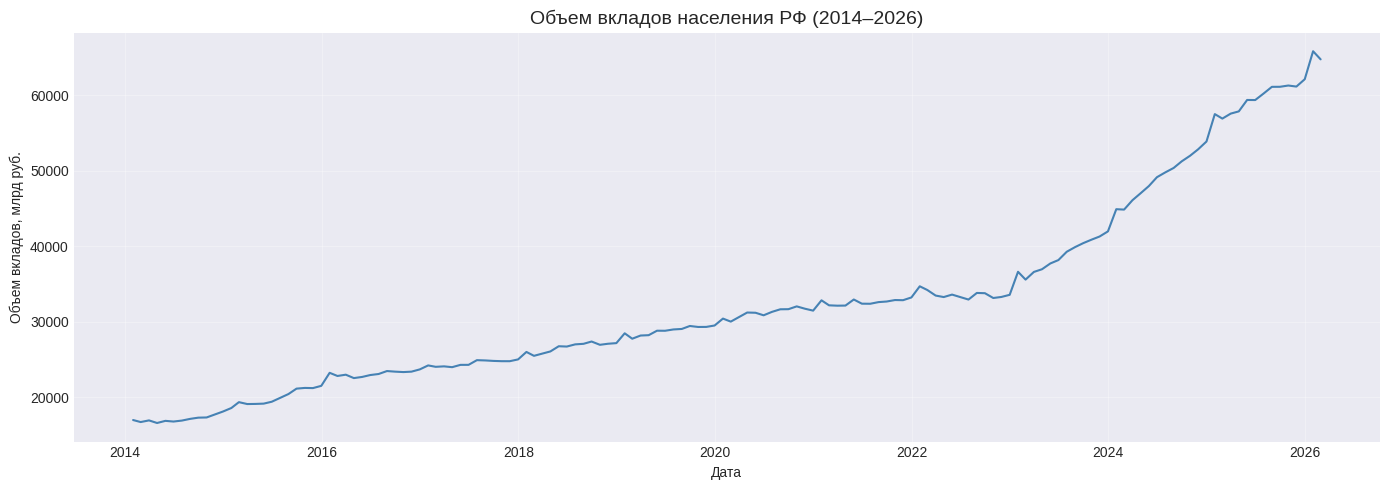


✅ Блок 1 завершен

БЛОК 2. УГЛУБЛЕННЫЙ АНАЛИЗ ВРЕМЕННЫХ РЯДОВ

🔍 Декомпозиция временного ряда (аддитивная модель)...


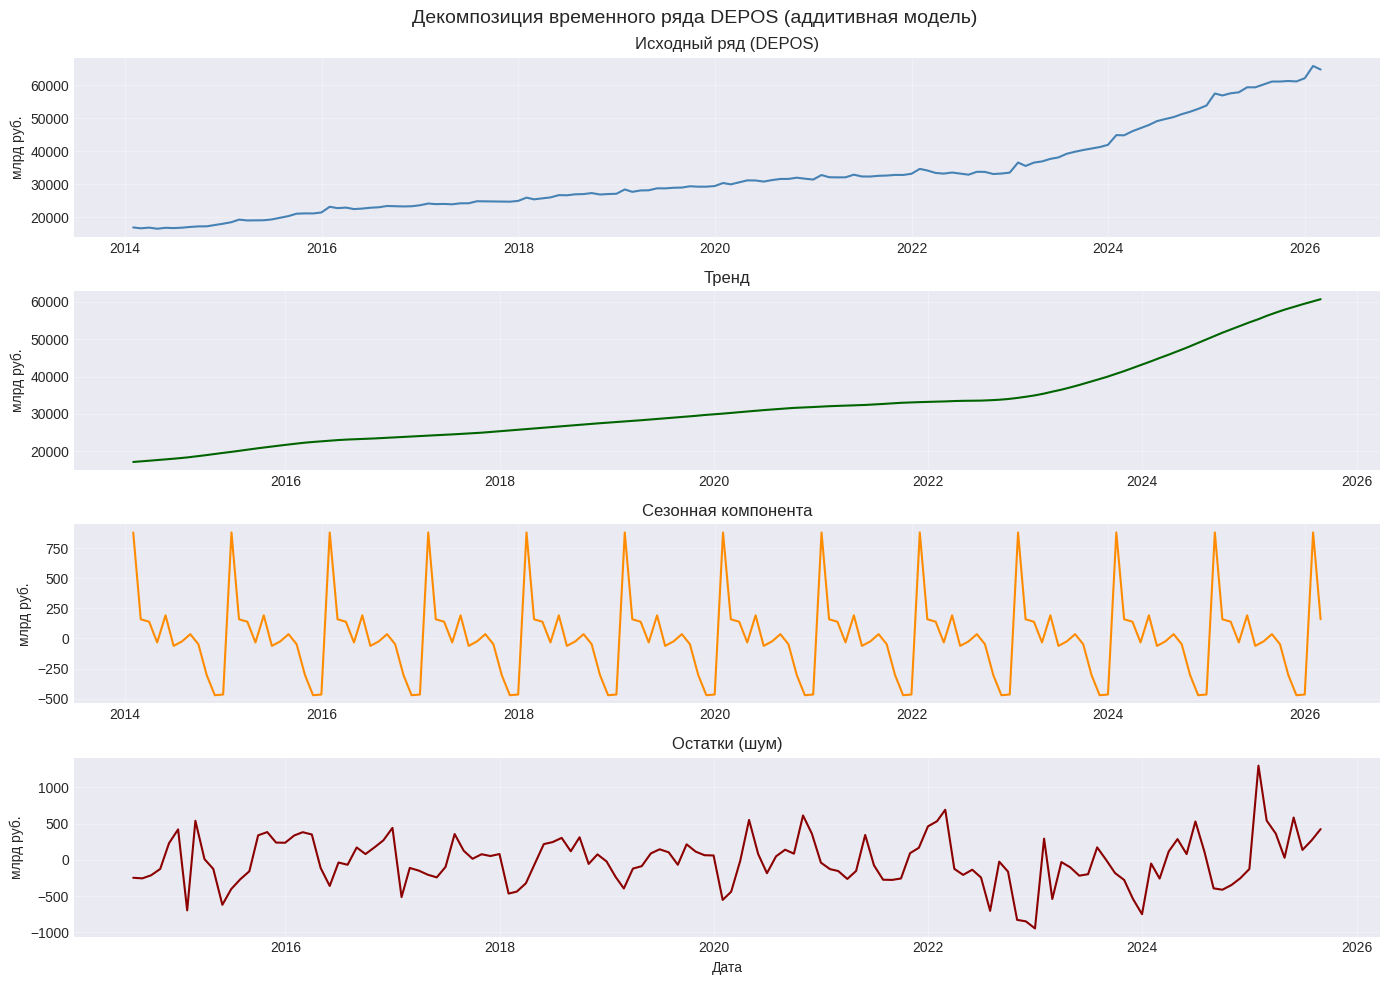


✅ Декомпозиция выполнена
   📌 Сезонная компонента выделена методом скользящего среднего (period=12)

🔍 Анализ сезонности...

📊 СЕЗОННОСТЬ (основные показатели):
   🔺 ПИК: Янв (+881.8 млрд руб.)
      Среднее значение в этом месяце: 33866.2 млрд руб.
   🔻 МИНИМУМ: Ноя (-471.8 млрд руб.)
      Среднее значение в этом месяце: 33049.4 млрд руб.
   📊 Размах сезонных колебаний: 1353.6 млрд руб.
      Это составляет 4.16% от среднего объема вкладов (32547 млрд руб.)

📋 Детальная таблица сезонности по месяцам:


,Среднее значение (млрд руб.),Сезонная компонента (млрд руб.)
Янв,33866.2,881.8
Фев,33431.9,159.6
Мар,31123.2,139.3
Апр,31241.8,-33.0
Май,31776.2,192.6
Июн,31839.5,-61.8
Июл,32220.8,-24.5
Авг,32618.0,35.8
Сен,32859.6,-47.8
Окт,32923.3,-304.3


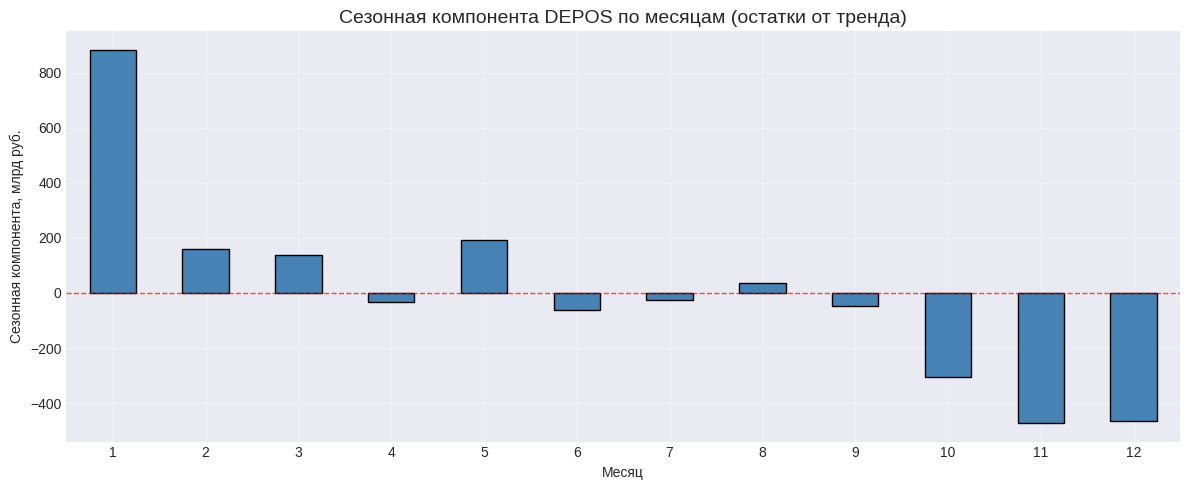


🔍 Проверка стационарности (ADF-тест)...

  DEPOS:
    ADF-статистика: 0.3935
    p-значение: 0.9813
    Вывод: Нестационарный ❌

🔍 Тест Чоу на структурный разрыв...

📊 Результаты теста Чоу:
   F-статистика: 782.0366
   p-значение: 0.0000

📌 ВЫВОД: Структурный разрыв статистически значим (p < 0.05)
   → Рекомендуется добавить фиктивную переменную (dummy) для периода после 2022


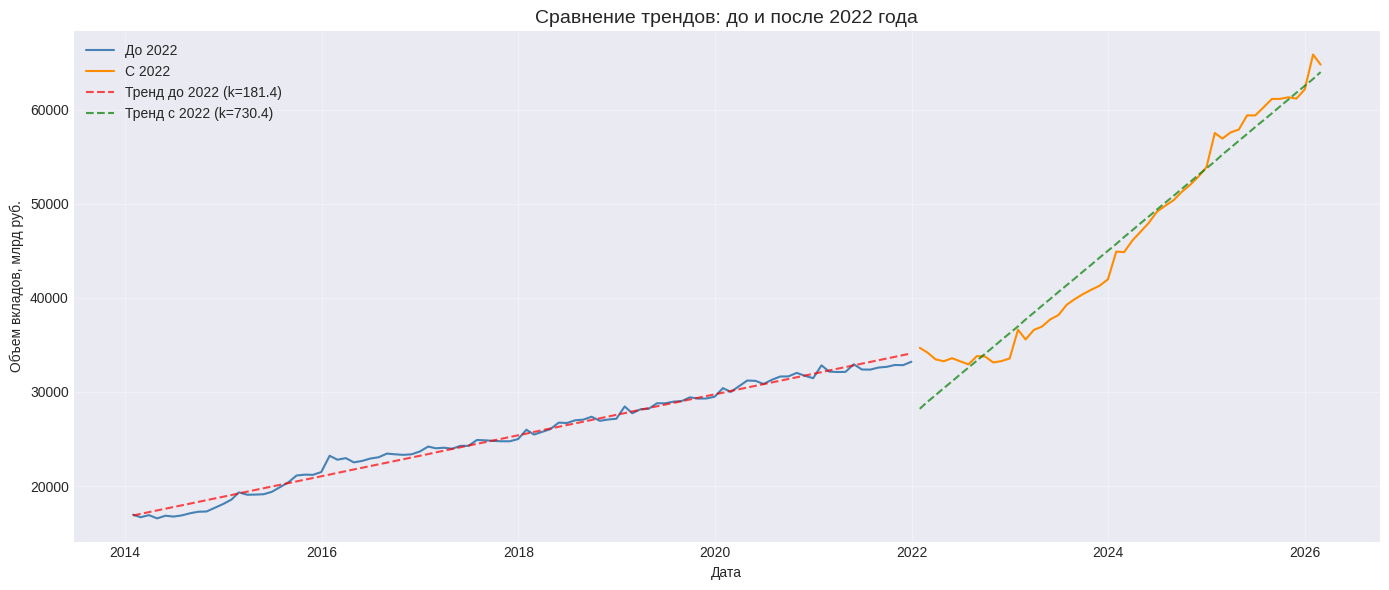


📊 Угол наклона тренда:
   До 2022: 181.43 млрд руб./месяц
   С 2022: 730.45 млрд руб./месяц
   Изменение: 302.6%

✅ Блок 2 завершен


In [6]:
# ============================================================
# УГЛУБЛЕННЫЙ АНАЛИЗ ВРЕМЕННЫХ РЯДОВ
# Проект: Прогнозирование объема вкладов населения РФ
# Автор: Надежда Силкина
# Дата: 2026
# ============================================================

# ============================================================
# БЛОК 1. ЗАГРУЗКА ДАННЫХ И КРАТКИЙ EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Библиотеки загружены")

# 1.1. Загрузка данных
url = 'https://raw.githubusercontent.com/HopeSilkina/deposits_forecast_project/main/data/processed_deposits_data.xlsx'
df = pd.read_excel(url, sheet_name='data')

# Преобразование дат
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f"✅ Данные загружены. Записей: {len(df)}")
print(f"Период: с {df.index.min()} по {df.index.max()}")

# 1.2. Краткий EDA (для напоминания)
print("\n" + "="*60)
print("КРАТКИЙ EDA (напоминание)")
print("="*60)

print("\n📊 Первые 5 строк:")
print(df.head())

print("\n📊 Описательные статистики (DEPOS):")
print(df['DEPOS'].describe())

# Визуализация DEPOS (быстрый график)
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['DEPOS'], color='steelblue', linewidth=1.5)
plt.title('Объем вкладов населения РФ (2014–2026)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Объем вкладов, млрд руб.')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('depos_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Блок 1 завершен")

# ============================================================
# БЛОК 2. УГЛУБЛЕННЫЙ АНАЛИЗ ВРЕМЕННЫХ РЯДОВ
# ============================================================

print("\n" + "="*60)
print("БЛОК 2. УГЛУБЛЕННЫЙ АНАЛИЗ ВРЕМЕННЫХ РЯДОВ")
print("="*60)

# 2.1. Декомпозиция временного ряда (аддитивная)
print("\n🔍 Декомпозиция временного ряда (аддитивная модель)...")

decomposition = seasonal_decompose(df['DEPOS'], model='additive', period=12)

# Визуализация компонент
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(df.index, df['DEPOS'], color='steelblue', linewidth=1.5)
axes[0].set_title('Исходный ряд (DEPOS)', fontsize=12)
axes[0].set_ylabel('млрд руб.')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend, color='darkgreen', linewidth=1.5)
axes[1].set_title('Тренд', fontsize=12)
axes[1].set_ylabel('млрд руб.')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal, color='darkorange', linewidth=1.5)
axes[2].set_title('Сезонная компонента', fontsize=12)
axes[2].set_ylabel('млрд руб.')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition.resid, color='darkred', linewidth=1.5)
axes[3].set_title('Остатки (шум)', fontsize=12)
axes[3].set_ylabel('млрд руб.')
axes[3].set_xlabel('Дата')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Декомпозиция временного ряда DEPOS (аддитивная модель)', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('decomposition_additive.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Декомпозиция выполнена")
print("   📌 Сезонная компонента выделена методом скользящего среднего (period=12)")

# 2.2. Анализ сезонности: средние значения и остатки по месяцам
print("\n🔍 Анализ сезонности...")

# Создаем копию для анализа
df_seasonal = df.copy()
df_seasonal['Month'] = df_seasonal.index.month
df_seasonal['Trend'] = decomposition.trend
df_seasonal['Seasonal'] = decomposition.seasonal
df_seasonal['Resid'] = decomposition.resid

# Средние значения по месяцам
monthly_avg = df_seasonal.groupby('Month')['DEPOS'].mean()
monthly_seasonal = df_seasonal.groupby('Month')['Seasonal'].mean()

# Собираем таблицу (для скрытого блока)
seasonal_table = pd.DataFrame({
    'Среднее значение (млрд руб.)': monthly_avg.round(1),
    'Сезонная компонента (млрд руб.)': monthly_seasonal.round(1)
})

month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
seasonal_table.index = month_names

# Статистика по сезонной компоненте
peak_month = monthly_seasonal.idxmax()
peak_value = monthly_seasonal.max()
peak_avg = monthly_avg[peak_month]
low_month = monthly_seasonal.idxmin()
low_value = monthly_seasonal.min()
low_avg = monthly_avg[low_month]
range_seasonal = peak_value - low_value

# Названия месяцев
peak_name = month_names[peak_month - 1]
low_name = month_names[low_month - 1]

# Средний объем вкладов
mean_depos = df['DEPOS'].mean()
seasonal_percent = (range_seasonal / mean_depos) * 100

# Вывод основных результатов (компактно)
print("\n📊 СЕЗОННОСТЬ (основные показатели):")
print(f"   🔺 ПИК: {peak_name} (+{peak_value:.1f} млрд руб.)")
print(f"      Среднее значение в этом месяце: {peak_avg:.1f} млрд руб.")
print(f"   🔻 МИНИМУМ: {low_name} ({low_value:.1f} млрд руб.)")
print(f"      Среднее значение в этом месяце: {low_avg:.1f} млрд руб.")
print(f"   📊 Размах сезонных колебаний: {range_seasonal:.1f} млрд руб.")
print(f"      Это составляет {seasonal_percent:.2f}% от среднего объема вкладов ({mean_depos:.0f} млрд руб.)")

# Детальная таблица (скрыта по умолчанию, открывается по запросу)
from IPython.display import HTML, display

table_html = seasonal_table.to_html()

print("\n📋 Детальная таблица сезонности по месяцам:")
display(HTML(f"""
<details>
    <summary><b>Нажмите, чтобы развернуть</b></summary>
    {table_html}
</details>
"""))

# Визуализация сезонной компоненты
plt.figure(figsize=(12, 5))
monthly_seasonal.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Сезонная компонента DEPOS по месяцам (остатки от тренда)', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Сезонная компонента, млрд руб.')
plt.xticks(rotation=0)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('seasonal_component.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.3. Проверка стационарности (ADF-тест)
print("\n🔍 Проверка стационарности (ADF-тест)...")

def adf_test(series, series_name):
    result = adfuller(series, autolag='AIC')
    print(f"\n  {series_name}:")
    print(f"    ADF-статистика: {result[0]:.4f}")
    print(f"    p-значение: {result[1]:.4f}")
    print(f"    Вывод: {'Стационарный ✅' if result[1] < 0.05 else 'Нестационарный ❌'}")

adf_test(df['DEPOS'], 'DEPOS')

# 2.4. Тест Чоу на структурный разрыв
print("\n🔍 Тест Чоу на структурный разрыв...")

df_before = df[df.index < '2022-01-01'].copy()
df_after = df[df.index >= '2022-01-01'].copy()

df_before['t'] = range(len(df_before))
df_after['t'] = range(len(df_after))

def calculate_rss(df, dep_var, ind_var):
    from sklearn.linear_model import LinearRegression
    X = df[[ind_var]].values
    y = df[dep_var].values
    model = LinearRegression().fit(X, y)
    residuals = y - model.predict(X)
    return np.sum(residuals**2)

df_combined = pd.concat([df_before, df_after])
df_combined['t'] = range(len(df_combined))
rss_combined = calculate_rss(df_combined, 'DEPOS', 't')

rss_before = calculate_rss(df_before, 'DEPOS', 't')
rss_after = calculate_rss(df_after, 'DEPOS', 't')
rss_separate = rss_before + rss_after

k = 2
n = len(df_combined)

f_stat = ((rss_combined - rss_separate) / k) / (rss_separate / (n - 2*k))
p_value = 1 - stats.f.cdf(f_stat, k, n - 2*k)

print(f"\n📊 Результаты теста Чоу:")
print(f"   F-статистика: {f_stat:.4f}")
print(f"   p-значение: {p_value:.4f}")

if p_value < 0.05:
    print("\n📌 ВЫВОД: Структурный разрыв статистически значим (p < 0.05)")
    print("   → Рекомендуется добавить фиктивную переменную (dummy) для периода после 2022")
else:
    print("\n📌 ВЫВОД: Структурный разрыв не подтверждается (p >= 0.05)")

# 2.5. Визуализация структурного разрыва
df_before_plot = df[df.index < '2022-01-01']
df_after_plot = df[df.index >= '2022-01-01']

plt.figure(figsize=(14, 6))
plt.plot(df_before_plot.index, df_before_plot['DEPOS'],
         color='steelblue', linewidth=1.5, label='До 2022')
plt.plot(df_after_plot.index, df_after_plot['DEPOS'],
         color='darkorange', linewidth=1.5, label='С 2022')

z1 = np.polyfit(range(len(df_before_plot)), df_before_plot['DEPOS'], 1)
p1 = np.poly1d(z1)
plt.plot(df_before_plot.index, p1(range(len(df_before_plot))),
         'r--', linewidth=1.5, alpha=0.7, label=f'Тренд до 2022 (k={z1[0]:.1f})')

z2 = np.polyfit(range(len(df_after_plot)), df_after_plot['DEPOS'], 1)
p2 = np.poly1d(z2)
plt.plot(df_after_plot.index, p2(range(len(df_after_plot))),
         'g--', linewidth=1.5, alpha=0.7, label=f'Тренд с 2022 (k={z2[0]:.1f})')

plt.title('Сравнение трендов: до и после 2022 года', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Объем вкладов, млрд руб.')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('structural_break_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Угол наклона тренда:")
print(f"   До 2022: {z1[0]:.2f} млрд руб./месяц")
print(f"   С 2022: {z2[0]:.2f} млрд руб./месяц")
print(f"   Изменение: {((z2[0] - z1[0]) / z1[0] * 100):.1f}%")

print("\n✅ Блок 2 завершен")